# CP8305 Final Project
## Notebook 3 – Modeling (Diabetes 130-US Hospitals)

### Objectives
- Load the processed Diabetes 130-US dataset.
- Train and compare a comprehensive set of classifiers via leakage-safe 10-fold stratified CV.
- Evaluate with AUC-ROC, AUPRC, F1, Cohen's Kappa, 95% CIs, and statistical significance tests.
- Conduct cost-sensitive threshold tuning aligned to HRRP readmission penalties.
- Produce SHAP, permutation importance, and PDP explainability artifacts.
- Export human-readable rules from tree-based models.

#### The methods we are using
* group-k-fold cross validation with confidence interval
-- we need group-k-fold to avoid data leakage since we have multiple encounters for the same patient.
* Kappa Statistic

#### Models

**Baselines:** ZeroR (majority class), OneR (single-split decision stump)

**Interpretable:** Gaussian Naive Bayes, Logistic Regression, SGDClassifier (log loss), Decision Tree (CART), kNN

**Ensemble:** Random Forest, Gradient Boosting, XGBoost, LightGBM

**Explainability:** SHAP, LIME, Permutation Importance, Partial Dependence Plots, Decision Rule Export


#### Metrics
* Accuracy & Balanced Accuracy
* Precision, Recall, F1, Weighted F1
* AUC-ROC, AUPRC (critical for imbalanced data)
* Cohen's Kappa (chance-corrected agreement)
* Precision@K and Recall@K (top-5%, top-10% operational capacity)
* Brier Score (calibration quality)
* 95% Confidence Intervals from fold distributions
* Paired t-test and Wilcoxon signed-rank significance tests

#### Evaluation Approach
All experiments use **Stratified 10-Fold Cross-Validation** with group-aware splitting (via `patient_nbr`) to prevent data leakage from repeated encounters. Preprocessing (scaling, SMOTE) is applied **strictly within each training fold**. Hyperparameter tuning uses **nested CV** (inner 5-fold) to produce unbiased performance estimates.

## 1. Setup

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path('..').resolve()))

import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.modeling import (
    split_data,
    get_stratified_cv,
    CLASSIFICATION_MODELS,
    CLASSIFICATION_MODELS_FAST,
    CLASSIFICATION_MODELS_ADVANCED,
    HYPERPARAM_GRIDS,
    SCALE_SENSITIVE_MODELS,
    build_fold_pipeline,
    compute_classification_metrics,
    compute_topk_metrics,
    compute_confidence_interval,
    run_cv_experiment,
    build_metrics_summary_table,
    run_significance_tests,
    compute_calibration_diagnostics,
    calibrate_model,
    compute_expected_cost,
    sweep_thresholds_cost,
    DEFAULT_COST_MATRIX,
    compute_shap_values,
    export_tree_rules,
    export_forest_top_rules,
    run_tuned_cv_experiment,
    compare_imbalance_strategies,
    predict_positive_probability,
    tune_decision_threshold,
    select_features_l1,
    train_classifier,
    evaluate_classifier,
    save_model,
    SHAP_AVAILABLE,
    LIME_AVAILABLE,
)
from src.visualization import (
    plot_confusion_matrix,
    plot_feature_importance,
    plot_permutation_importance,
    plot_roc_curves,
    plot_pr_curves,
    plot_calibration_curves,
    plot_model_comparison,
    plot_confidence_intervals,
    plot_cost_threshold_sweep,
    plot_shap_summary,
    plot_pdp,
    save_figure,
)

np.random.seed(42)
sns.set_theme(style='whitegrid')
%matplotlib inline

## 2. Load Processed Data

In [2]:
DATA_FILE = Path('..') / 'data' / 'processed' / 'processed_dataset.csv'
df = pd.read_csv(DATA_FILE)
print(f'Shape: {df.shape}')
df.head()

Shape: (69990, 2473)


,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses,readmitted_binary,age_ordinal,...,admission_type_group_other,admission_type_group_urgent,discharge_group_inpatient,discharge_group_left_ama,discharge_group_other,discharge_group_transfer,admission_source_group_newborn,admission_source_group_other,admission_source_group_referral,admission_source_group_transfer
0,13,68,2,28,0,0,0,8,0,9,...,False,True,False,False,False,False,False,False,False,True
1,12,33,3,18,0,0,0,8,0,10,...,False,False,False,False,False,True,False,False,False,True
2,1,51,0,8,0,0,0,5,0,5,...,False,False,False,False,False,False,False,False,False,False
3,9,47,2,17,0,0,0,9,0,5,...,False,False,False,False,False,False,False,False,False,False
4,3,31,6,16,0,0,0,9,0,6,...,False,True,False,False,False,False,False,False,True,False


## 3. Feature / Target Split

In [3]:
# Target column used in preprocessing notebook.
TARGET = 'readmitted_binary'

# Keep patient_nbr only for optional group-aware CV, never as a model feature.
group_ids = df['patient_nbr'].copy() if 'patient_nbr' in df.columns else None

drop_columns = [TARGET]
for leakage_col in ['encounter_id', 'patient_nbr']:
    if leakage_col in df.columns:
        drop_columns.append(leakage_col)

X = df.drop(columns=drop_columns)
y = df[TARGET]

print(f'Features: {X.shape[1]}  |  Target: {y.name}  |  Classes/Values: {y.nunique()}')
if group_ids is not None:
    print('Group-aware CV is enabled via patient_nbr (excluded from X).')
else:
    print('Group-aware CV unavailable (patient_nbr not present in processed data).')

Features: 2472  |  Target: readmitted_binary  |  Classes/Values: 2
Group-aware CV unavailable (patient_nbr not present in processed data).


In [4]:
# Split once up-front with stratification so class imbalance is preserved.
X_train, X_test, y_train, y_test = split_data(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=True,
 )

# If group IDs are available, keep the train-split groups for CV-only use.
groups_train = group_ids.loc[X_train.index] if group_ids is not None else None

print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')
print(f'Positive class ratio (train): {y_train.mean():.4f}')
print(f'Positive class ratio (test) : {y_test.mean():.4f}')

Train: (55992, 2472)  |  Test: (13998, 2472)
Positive class ratio (train): 0.0898
Positive class ratio (test) : 0.0898


In [5]:
# Run L1-based feature selection on training data only to avoid leakage.
selected_columns, l1_selector_model = select_features_l1(X_train, y_train, C=0.1)

X_train_fs = X_train[selected_columns].copy()
X_test_fs = X_test[selected_columns].copy()

print(f'Selected features for optional reduced model: {len(selected_columns)}')

/Users/chrisindris/.pyenv/versions/3.11.11/envs/cp8305fp/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


L1 feature selection kept 2472 of 2472 features.
Selected features for optional reduced model: 2472


---
## 4. Classification – Unified CV Experiment
All candidate models are evaluated under identical fold-local pipelines (scaler → classifier) to ensure fair, leakage-free comparison across 10 stratified folds.

In [6]:
# Run 10-fold stratified CV with fold-local pipelines for all registered models.
# Preprocessing (scaling) is fit strictly on training folds to prevent leakage.
experiment_results = run_cv_experiment(
    X_train, y_train,
    model_configs=CLASSIFICATION_MODELS_FAST,
    n_splits=10,
    groups=groups_train,
    scale=True,
    imbalance_strategy='none',
    random_state=42,
)


  Model: zero_r
  Fold  1: F1=0.0000  AUC=0.5000  Kappa=0.0000
  Fold  2: F1=0.0000  AUC=0.5000  Kappa=0.0000
  Fold  3: F1=0.0000  AUC=0.5000  Kappa=0.0000
  Fold  4: F1=0.0000  AUC=0.5000  Kappa=0.0000
  Fold  5: F1=0.0000  AUC=0.5000  Kappa=0.0000
  Fold  6: F1=0.0000  AUC=0.5000  Kappa=0.0000
  Fold  7: F1=0.0000  AUC=0.5000  Kappa=0.0000
  Fold  8: F1=0.0000  AUC=0.5000  Kappa=0.0000
  Fold  9: F1=0.0000  AUC=0.5000  Kappa=0.0000
  Fold 10: F1=0.0000  AUC=0.5000  Kappa=0.0000
            f1: 0.0000 [0.0000, 0.0000]
       auc_roc: 0.5000 [0.5000, 0.5000]
         kappa: 0.0000 [0.0000, 0.0000]

  Model: one_r
  Fold  1: F1=0.0000  AUC=0.5700  Kappa=0.0000
  Fold  2: F1=0.0000  AUC=0.5818  Kappa=0.0000
  Fold  3: F1=0.0000  AUC=0.5602  Kappa=0.0000
  Fold  4: F1=0.0000  AUC=0.5696  Kappa=0.0000
  Fold  5: F1=0.0000  AUC=0.5881  Kappa=0.0000
  Fold  6: F1=0.0000  AUC=0.5702  Kappa=0.0000
  Fold  7: F1=0.0000  AUC=0.5693  Kappa=0.0000
  Fold  8: F1=0.0000  AUC=0.5707  Kappa=0.0000
 

/Users/chrisindris/.pyenv/versions/3.11.11/envs/cp8305fp/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/chrisindris/.pyenv/versions/3.11.11/envs/cp8305fp/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


  Fold  1: F1=0.0000  AUC=0.6452  Kappa=-0.0018


/Users/chrisindris/.pyenv/versions/3.11.11/envs/cp8305fp/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/chrisindris/.pyenv/versions/3.11.11/envs/cp8305fp/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


  Fold  2: F1=0.0117  AUC=0.6694  Kappa=0.0086


...

/Users/chrisindris/.pyenv/versions/3.11.11/envs/cp8305fp/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/chrisindris/.pyenv/versions/3.11.11/envs/cp8305fp/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


  Fold  9: F1=0.0118  AUC=0.6572  Kappa=0.0093


/Users/chrisindris/.pyenv/versions/3.11.11/envs/cp8305fp/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


  Fold 10: F1=0.0079  AUC=0.6772  Kappa=0.0065
            f1: 0.0098 [0.0068, 0.0129]
       auc_roc: 0.6499 [0.6384, 0.6613]
         kappa: 0.0078 [0.0050, 0.0107]


/Users/chrisindris/.pyenv/versions/3.11.11/envs/cp8305fp/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


=== Model Comparison (sorted by F1, with 95% CIs) ===


,f1_mean,f1_std,f1_ci_lower,f1_ci_upper,auc_roc_mean,auc_roc_std,auc_roc_ci_lower,auc_roc_ci_upper,auprc_mean,auprc_std,...,kappa_ci_lower,kappa_ci_upper,brier_score_mean,brier_score_std,brier_score_ci_lower,brier_score_ci_upper,balanced_accuracy_mean,balanced_accuracy_std,balanced_accuracy_ci_lower,balanced_accuracy_ci_upper
model,,,,,,,,,,,,,,,,,,,,,
sgd_classifier,0.184895,0.007779,0.179331,0.190460,0.573094,0.012248,0.564332,0.581856,0.113926,0.005751,...,0.037466,0.050372,0.298740,0.010889,0.290951,0.306530,0.557540,0.012114,0.548874,0.566206
naive_bayes,0.167424,0.001189,0.166573,0.168275,0.511860,0.003393,0.509433,0.514287,0.091786,0.000600,...,0.003674,0.005525,0.838191,0.003511,0.835679,0.840703,0.511860,0.003393,0.509433,0.514287
decision_tree,0.126223,0.008589,0.120080,0.132367,0.520607,0.004759,0.517202,0.524012,0.094721,0.001550,...,0.034845,0.049339,0.153611,0.003855,0.150854,0.156369,0.520607,0.004759,0.517202,0.524012
logistic_regression,0.032857,0.009590,0.025997,0.039718,0.621391,0.012121,0.612720,0.630062,0.150701,0.012159,...,0.016258,0.028633,0.082539,0.001162,0.081708,0.083370,0.506494,0.002516,0.504694,0.508294
xgboost,0.031745,0.014618,0.021288,0.042202,0.638605,0.016823,0.626571,0.650640,0.169632,0.018992,...,0.015589,0.035326,0.079842,0.001044,0.079096,0.080589,0.507222,0.003957,0.504392,0.510053
knn,0.030574,0.008219,0.024695,0.036454,0.536101,0.010763,0.528402,0.543801,0.101709,0.003365,...,0.012717,0.023025,0.094198,0.001159,0.093369,0.095028,0.505231,0.002143,0.503699,0.506764
lightgbm,0.009826,0.004232,0.006799,0.012853,0.649867,0.015975,0.638439,0.661294,0.177519,0.012485,...,0.004992,0.010671,0.079033,0.000564,0.078629,0.079437,0.502172,0.001102,0.501384,0.502961
gradient_boosting,0.005517,0.004593,0.002231,0.008803,0.651797,0.014635,0.641328,0.662265,0.173837,0.010537,...,0.001477,0.007236,0.079211,0.000363,0.078951,0.079470,0.501205,0.001119,0.500405,0.502006
random_forest,0.000397,0.001255,-0.000501,0.001295,0.625018,0.009236,0.618412,0.631625,0.163896,0.009985,...,-0.000552,0.001132,0.079871,0.000408,0.079579,0.080163,0.500080,0.000324,0.499848,0.500311



Best model by CV F1: sgd_classifier
Figure saved to /Users/chrisindris/Documents/PhD/CP8305-KD/Project/CP8305FP/reports/figures/03_f1_confidence_intervals.png


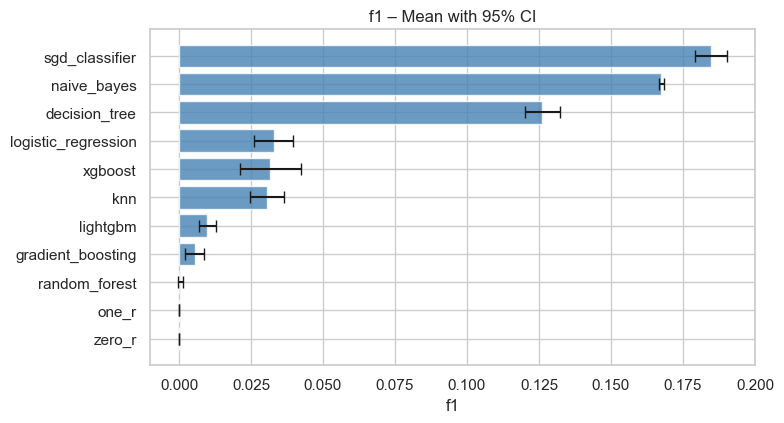

Figure saved to /Users/chrisindris/Documents/PhD/CP8305-KD/Project/CP8305FP/reports/figures/03_model_comparison.png


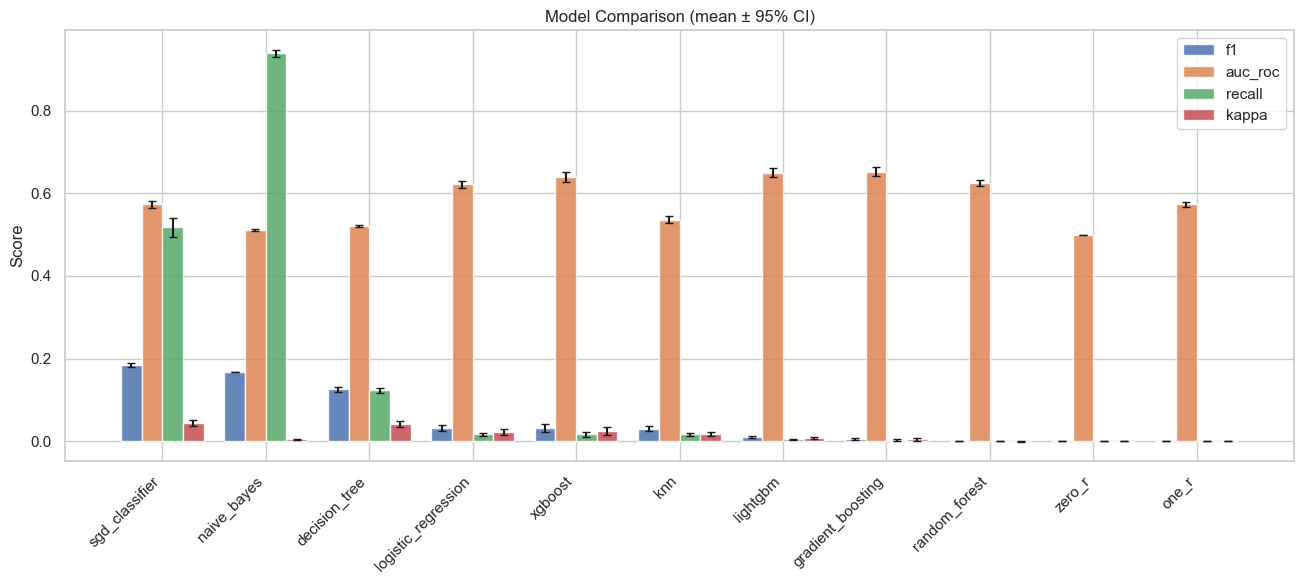

In [7]:
# Build the metrics summary table with 95% CIs from fold distributions.
summary_table = build_metrics_summary_table(experiment_results)
print('=== Model Comparison (sorted by F1, with 95% CIs) ===')
display(summary_table)

# Identify best model.
BEST_CLF = summary_table.index[0]
print(f'\nBest model by CV F1: {BEST_CLF}')

# Forest plot of F1 confidence intervals.
fig = plot_confidence_intervals(summary_table, metric='f1')
save_figure(fig, '03_f1_confidence_intervals.png')
plt.show()

# Grouped bar chart across key metrics.
fig = plot_model_comparison(summary_table, metrics=['f1', 'auc_roc', 'recall', 'kappa'])
save_figure(fig, '03_model_comparison.png')
plt.show()

---
## 4.5 SGDClassifier on reduced features (fold-local)

Training **SGDClassifier** on the full ~2.5k one-hot columns is possible but slow; here we compare three **fold-local** reductions first (fit on the training fold only, transform the validation fold—same leakage posture as scaling), then fit SGD on the reduced matrix.

**RFECV** at full dimension would require enormous numbers of model refits per fold. **SelectFromModel** with an ensemble is the practical substitute at this scale; if you need RFECV for a write-up, restrict it to a low-dimensional input (for example after PCA to 50 components) and use a large `step` to limit refits.

The next cell uses **lightweight defaults** for faster runs: **10-fold** CV (same as Section 4), **PCA** with 32 components, **SelectKBest** with `k=20`, and **SelectFromModel** capped with `max_features=20`, plus a smaller ensemble for the selector. Increase PCA / k / `max_features` if you need richer features.

In [ ]:
from sklearn.base import clone

# Tree/boosting model for SelectFromModel: best mean F1 among advanced models in this CV run.
_advanced_in_run = [
    k for k in CLASSIFICATION_MODELS_ADVANCED
    if k in experiment_results and k in CLASSIFICATION_MODELS
]
if _advanced_in_run:
    ref_tree_name = max(
        _advanced_in_run,
        key=lambda k: experiment_results[k]["aggregate"]["f1"]["mean"],
    )
else:
    ref_tree_name = next(
        k for k in ("lightgbm", "xgboost", "random_forest") if k in CLASSIFICATION_MODELS
    )

selector_base = clone(CLASSIFICATION_MODELS[ref_tree_name])
if hasattr(selector_base, "set_params"):
    if ref_tree_name == "lightgbm":
        selector_base.set_params(n_estimators=20, num_leaves=31, max_depth=5, verbose=-1)
    elif ref_tree_name == "xgboost":
        selector_base.set_params(n_estimators=20, max_depth=4, verbosity=0)
    elif ref_tree_name == "catboost":
        selector_base.set_params(iterations=20, depth=5, verbose=0)
    elif ref_tree_name in ("random_forest", "gradient_boosting"):
        selector_base.set_params(n_estimators=25)

print(
    f"SelectFromModel base estimator: {ref_tree_name} "
    "(lighter settings than full CV models for speed)"
)

SGD_REDUCED_MODELS = {"sgd_classifier": CLASSIFICATION_MODELS["sgd_classifier"]}


def _prefix_experiment_results(results: dict, prefix: str) -> dict:
    return {f"{prefix}__{name}": out for name, out in results.items()}


sgd_reduced_results = {}
sgd_reduced_results.update(
    _prefix_experiment_results(
        run_cv_experiment(
            X_train,
            y_train,
            model_configs=SGD_REDUCED_MODELS,
            n_splits=10,
            groups=groups_train,
            scale=True,
            imbalance_strategy="class_weight",
            random_state=42,
            reduction=("pca", {"n_components": 32}),
        ),
        "pca32",
    )
)
sgd_reduced_results.update(
    _prefix_experiment_results(
        run_cv_experiment(
            X_train,
            y_train,
            model_configs=SGD_REDUCED_MODELS,
            n_splits=10,
            groups=groups_train,
            scale=True,
            imbalance_strategy="class_weight",
            random_state=42,
            reduction=("select_kbest", {"k": 20}),
        ),
        "kbest20",
    )
)
sgd_reduced_results.update(
    _prefix_experiment_results(
        run_cv_experiment(
            X_train,
            y_train,
            model_configs=SGD_REDUCED_MODELS,
            n_splits=10,
            groups=groups_train,
            scale=True,
            imbalance_strategy="class_weight",
            random_state=42,
            reduction=(
                "select_from_model",
                {
                    "estimator": selector_base,
                    "threshold": "median",
                    "max_features": 20,
                },
            ),
        ),
        "sfm_median",
    )
)

sgd_reduced_summary = build_metrics_summary_table(sgd_reduced_results)
print("=== SGDClassifier with fold-local dimensionality reduction (10-fold CV, light feature settings) ===")
display(sgd_reduced_summary)

In [ ]:
# Statistical significance: paired t-test and Wilcoxon signed-rank vs. baseline.
significance_df = run_significance_tests(
    experiment_results, baseline_model='zero_r', metric='f1', alpha=0.05,
)
print('=== Statistical Significance Tests (F1 vs. ZeroR baseline) ===')
display(significance_df)

# Also test against logistic regression as a stronger baseline.
significance_lr = run_significance_tests(
    experiment_results, baseline_model='logistic_regression', metric='f1', alpha=0.05,
)
print('\n=== Statistical Significance Tests (F1 vs. Logistic Regression) ===')
display(significance_lr)

KeyError: 'zero_r'

In [ ]:
# Compare class-imbalance strategies on train data only (fold-local pipelines).
print(f'Imbalance comparison for best model: {BEST_CLF}')
imbalance_results = compare_imbalance_strategies(
    X_train, y_train,
    model_name=BEST_CLF,
    cv=5,
    groups=groups_train,
    scoring='f1',
)
imbalance_df = pd.DataFrame(imbalance_results).T.sort_values('mean', ascending=False)
print('Imbalance strategy comparison (CV F1):')
display(imbalance_df)

In [ ]:
# Nested CV: inner 5-fold loop tunes hyperparameters, outer 10-fold loop evaluates.
# Only models with defined search spaces in HYPERPARAM_GRIDS are tuned.
top_models = {
    k: CLASSIFICATION_MODELS_FAST[k]
    for k in list(summary_table.index[:5])
    if k in HYPERPARAM_GRIDS
}
print(f'Tuning top models: {list(top_models.keys())}')

if top_models:
    tuned_results = run_tuned_cv_experiment(
        X_train, y_train,
        model_configs=top_models,
        param_grids=HYPERPARAM_GRIDS,
        n_outer_splits=10,
        n_inner_splits=5,
        groups=groups_train,
        scale=True,
        scoring='f1',
        random_state=42,
    )
    tuned_summary = build_metrics_summary_table(tuned_results)
    print('\n=== Tuned Model Comparison (Nested CV, unbiased) ===')
    display(tuned_summary)
else:
    print('No models have defined hyperparameter grids for tuning.')
    tuned_results = {}

In [ ]:
# Train the final best model on the full training set for holdout evaluation.
best_clf_pipeline = train_classifier(X_train, y_train, model_name=BEST_CLF, scale=True)
y_pred_test = best_clf_pipeline.predict(X_test)
y_prob_test = predict_positive_probability(best_clf_pipeline, X_test)

# Holdout set metrics (comprehensive suite).
test_metrics = compute_classification_metrics(y_test.values, y_pred_test, y_prob_test)
print(f'=== Holdout Test Metrics ({BEST_CLF}) ===')
for k, v in test_metrics.items():
    print(f'  {k:>20s}: {v:.4f}')

# Top-K metrics (operational capacity simulation).
topk = compute_topk_metrics(y_test.values, y_prob_test)
print('\n=== Top-K Metrics (capacity simulation) ===')
for label, vals in topk.items():
    print(f'  {label}: Precision@K={vals["precision_at_k"]:.4f}, Recall@K={vals["recall_at_k"]:.4f} (k={vals["k"]})')

In [ ]:
# ROC and Precision-Recall curves from out-of-fold probabilities.
fig = plot_roc_curves(experiment_results, y_train)
save_figure(fig, '03_roc_curves.png')
plt.show()

fig = plot_pr_curves(experiment_results, y_train)
save_figure(fig, '03_pr_curves.png')
plt.show()

# Confusion matrices: default threshold vs. recall-tuned threshold.
fig = plot_confusion_matrix(y_test, y_pred_test, title=f'{BEST_CLF} (threshold=0.50)')
save_figure(fig, '03_confusion_matrix.png')
plt.show()

threshold_results = tune_decision_threshold(y_test, y_prob_test, metric='recall')
best_threshold = threshold_results['best_threshold']
y_pred_tuned = (y_prob_test >= best_threshold).astype(int)

fig = plot_confusion_matrix(
    y_test, y_pred_tuned,
    title=f'{BEST_CLF} (threshold={best_threshold:.2f})',
)
save_figure(fig, '03_confusion_matrix_threshold_tuned.png')
plt.show()

---
## 5. Cost-Sensitive Business Evaluation
Evaluate models against an FN-heavy cost matrix aligned to Hospital Readmissions Reduction Program (HRRP) penalties. False negatives (missed readmissions) are far more costly than false positives (unnecessary interventions).

In [ ]:
# Cost matrix aligned to HRRP readmission penalties.
print('Cost matrix (per prediction outcome):')
for k, v in DEFAULT_COST_MATRIX.items():
    print(f'  {k}: ${v:,.0f}')

# Threshold sweep: expected cost and recall at each threshold.
cost_sweep = sweep_thresholds_cost(y_test.values, y_prob_test)

fig = plot_cost_threshold_sweep(cost_sweep)
save_figure(fig, '03_cost_threshold_sweep.png')
plt.show()

# Compare default vs. cost-optimal operating point.
best_cost_row = cost_sweep.sort_values('total_cost').iloc[0]
default_cost = compute_expected_cost(y_test.values, y_pred_test)

print(f'Cost-optimal threshold: {best_cost_row["threshold"]:.2f}')
print(f'  Total cost:  ${best_cost_row["total_cost"]:,.0f}')
print(f'  Recall:      {best_cost_row["recall"]:.4f}')
print(f'\nDefault threshold (0.50):')
print(f'  Total cost:  ${default_cost["total_cost"]:,.0f}')
print(f'  FN={default_cost["fn"]}, FP={default_cost["fp"]}')

In [ ]:
# Calibration diagnostics: do predicted probabilities match observed frequencies?
fig = plot_calibration_curves(experiment_results, y_train, n_bins=10)
save_figure(fig, '03_calibration_curves.png')
plt.show()

# Brier score for the best model on the holdout set.
cal_diag = compute_calibration_diagnostics(y_test.values, y_prob_test)
print(f'Brier score ({BEST_CLF}): {cal_diag["brier_score"]:.4f}')
print('(Lower is better; 0 = perfect calibration)')

---
## 6. Explainability (XAI) & Knowledge Discovery
SHAP global/local explanations, permutation importance, partial dependence plots, and human-readable rule export for clinical deployment.

In [ ]:
# SHAP global feature importance for the best model.
if SHAP_AVAILABLE:
    shap_values, shap_explainer, X_shap_sample = compute_shap_values(
        best_clf_pipeline, X_test, feature_names=list(X_train.columns),
    )
    fig = plot_shap_summary(shap_values, X_shap_sample, max_display=20)
    save_figure(fig, '03_shap_summary.png')
    plt.show()
else:
    print('SHAP not installed. Install via: pip install shap')

In [ ]:
# Permutation importance on holdout set (model-agnostic).
fig = plot_permutation_importance(best_clf_pipeline, X_test, y_test, top_n=20)
save_figure(fig, '03_permutation_importance.png')
plt.show()

# Partial Dependence Plots for top features (tree-based models only).
try:
    inner_model = best_clf_pipeline.named_steps.get('classifier')
    if hasattr(inner_model, 'feature_importances_'):
        top_idx = np.argsort(inner_model.feature_importances_)[::-1][:6]
        top_feature_names = [X_train.columns[i] for i in top_idx]
        fig = plot_pdp(best_clf_pipeline, X_test, top_feature_names)
        save_figure(fig, '03_partial_dependence.png')
        plt.show()
    else:
        print(f'PDP: {BEST_CLF} does not expose feature_importances_; skipping PDP.')
except Exception as e:
    print(f'PDP not available for this model type: {e}')

In [ ]:
# Extract human-readable decision rules for clinical deployment.
# Decision tree rules (full model).
dt_pipeline = train_classifier(X_train, y_train, model_name='decision_tree', scale=False)
dt_model = dt_pipeline.named_steps['classifier']
dt_rules = export_tree_rules(dt_model, feature_names=list(X_train.columns), max_depth=5)
print('=== Decision Tree Rules (max depth 5) ===')
print(dt_rules)

# Random forest top-tree rules (representative subset of the ensemble).
rf_pipeline = train_classifier(X_train, y_train, model_name='random_forest', scale=False)
rf_model = rf_pipeline.named_steps['classifier']
rf_rules = export_forest_top_rules(
    rf_model, feature_names=list(X_train.columns), n_trees=3, max_depth=3,
)
print('\n=== Random Forest – Top 3 Tree Rules (max depth 3) ===')
for rule in rf_rules:
    print(rule)

---
## Optional: Regression Models
_These sections are preserved for reference but are not part of the readmission classification analysis._

In [ ]:
reg_results = {}
for name in REGRESSION_MODELS:
    print(f'\n--- {name} ---')
    pipeline = train_regressor(X_train, y_train, model_name=name, scale=True)
    metrics = evaluate_regressor(pipeline, X_test, y_test)
    reg_results[name] = metrics

print('\n=== RMSE Summary ===')
for name, m in sorted(reg_results.items(), key=lambda x: x[1]['rmse']):
    print(f'{name:<25} RMSE={m["rmse"]:.4f}  R²={m["r2"]:.4f}')

In [ ]:
BEST_REG = min(reg_results, key=lambda k: reg_results[k]['rmse'])
best_reg_pipeline = train_regressor(X_train, y_train, model_name=BEST_REG, scale=True)
y_pred_reg = best_reg_pipeline.predict(X_test)

fig = plot_residuals(y_test, y_pred_reg, title=f'Residual Plot – {BEST_REG}')
save_figure(fig, '03_residuals.png')
plt.show()

---
## Optional: Clustering
_These sections are preserved for reference but are not part of the readmission classification analysis._

In [ ]:
from sklearn.preprocessing import StandardScaler

# Scale features before clustering
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

# Elbow method
elbow_data = find_optimal_k(X_scaled, k_range=range(2, 11))
fig = plot_elbow_curve(elbow_data)
save_figure(fig, '03_elbow_curve.png')
plt.show()

In [ ]:
# TODO: Set k based on the elbow plot above.
OPTIMAL_K = 3

kmeans_model, cluster_labels = train_kmeans(X_scaled, n_clusters=OPTIMAL_K)

# TODO: Replace 'feature_x' and 'feature_y' with two informative feature names.
# fig = plot_cluster_scatter(X_scaled, cluster_labels, 'feature_x', 'feature_y')
# save_figure(fig, '03_cluster_scatter.png')
# plt.show()

## 5. Feature Importance

In [ ]:
# Works for tree-based classifiers/regressors. Adapt model variable as needed.
# Assumes the last step in the pipeline is named 'classifier' or 'regressor'.
try:
    inner_model = best_clf_pipeline.named_steps.get('classifier') \
                  or best_clf_pipeline.named_steps.get('regressor')
    if hasattr(inner_model, 'feature_importances_'):
        fig = plot_feature_importance(inner_model, list(X.columns), top_n=20)
        save_figure(fig, '03_feature_importance.png')
        plt.show()
except Exception as e:
    print(f'Feature importance not available: {e}')

## 6. Save Best Model

In [ ]:
save_model(best_clf_pipeline, 'best_classifier.pkl')
print('Modeling complete. Proceed to Notebook 4 – Analysis & Findings.')